In [ ]:

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report 

# Import from our custom modules in the src/ folder
from NN.features import clean_and_engineer, prepare_model_data, FAT_TAIL_FEATURES
from NN.dataset import FinancialNeedsDataset
from NN.model import MultiTaskNeedsMLP
from NN.train import train_multitask_model

print("Setup complete. Custom modules loaded successfully.")



Setup complete. Custom modules loaded successfully.


In [2]:
import joblib
from pathlib import Path

# 1. Load + engineer
df = pd.read_excel('Dataset2_Needs.xls', sheet_name='Needs')
df_engineered = clean_and_engineer(df)

# 2. Strict 3-way split with fitted scalers returned (fix #1, #2)
(X_train, X_val, X_test,
 y_train, y_val, y_test,
 feature_cols, qt, rs) = prepare_model_data(df_engineered)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# 3. Persist scalers so inference in production uses the exact same transform (fix #2)
Path('artifacts').mkdir(exist_ok=True)
joblib.dump({'qt': qt, 'rs': rs, 'feature_cols': feature_cols},
            'artifacts/preprocessors.joblib')

# 4. Continuous mask for safe augmentation (fix #3)
#    Exclude ALL discrete / ordinal / bounded-category columns - noise on them
#    creates impossible users (e.g. 2.3 family members).
discrete_features = {
    'Gender', 'FamilyMembers', 'FinancialEducation',
    'LifeStage_working', 'LifeStage_retired',
}
continuous_mask = [col not in discrete_features for col in feature_cols]
print(f"Augmenting {sum(continuous_mask)}/{len(feature_cols)} features with Gaussian noise.")

# 5. PyTorch datasets - augmentation on TRAIN only
#train_dataset = FinancialNeedsDataset(X_train, y_train, augment=True,
#                                      noise_std=0.05, continuous_mask=continuous_mask)
train_dataset = FinancialNeedsDataset(X_train, y_train, augment=False) #best model was trained without augmentation
                                        

val_dataset   = FinancialNeedsDataset(X_val,   y_val,   augment=False)
test_dataset  = FinancialNeedsDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=64,  shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

Train: (3200, 20) | Val: (800, 20) | Test: (1000, 20)
Augmenting 15/20 features with Gaussian noise.


In [3]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score
import time

print("--- EVALUATING SVM BASELINE ON ENGINEERED FEATURES ---\n")

def evaluate_svm_baseline(X_tr, y_tr, X_v, y_v, target_name):
    print(f"Target: {target_name}")
    print("="*40)
    
    start_time = time.time()
    
    # Support Vector Machine
    # class_weight='balanced' is crucial for the imbalanced Income target
    svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
    svm_model.fit(X_tr, y_tr)
    
    svm_preds = svm_model.predict_proba(X_v)[:, 1]
    svm_pred_class = svm_model.predict(X_v)
    
    auc = roc_auc_score(y_v, svm_preds)
    f1 = f1_score(y_v, svm_pred_class)
    
    print(f"SVM ROC-AUC     : {auc:.4f}")
    print(f"SVM F1-Score    : {f1:.4f}")
    print(f"Training Time   : {time.time() - start_time:.2f} seconds\n")
    
    return svm_model

# Evaluate Income
svm_inc = evaluate_svm_baseline(
    X_train, y_train['IncomeInvestment'], 
    X_val, y_val['IncomeInvestment'], 
    "Income Investment"
)

# Evaluate Accumulation
svm_acc = evaluate_svm_baseline(
    X_train, y_train['AccumulationInvestment'], 
    X_val, y_val['AccumulationInvestment'], 
    "Accumulation Investment"
)

--- EVALUATING SVM BASELINE ON ENGINEERED FEATURES ---

Target: Income Investment
SVM ROC-AUC     : 0.7294
SVM F1-Score    : 0.6335
Training Time   : 1.90 seconds

Target: Accumulation Investment
SVM ROC-AUC     : 0.8536
SVM F1-Score    : 0.7817
Training Time   : 1.50 seconds



In [4]:
import torch.nn as nn
import torch.nn.functional as F

# 1. Define the Single-Task Architecture (Exact same capacity as one branch of the Multi-Task model)
class SingleTaskMLP(nn.Module):
    def __init__(self, in_dim, trunk=(64, 32), head=(16,), p=0.25):
        super().__init__()
        layers, d = [], in_dim
        
        # Trunk
        for h in trunk:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(p)]
            d = h
            
        # Head
        for h in head:
            layers += [nn.Linear(d, h), nn.GELU(), nn.Dropout(p)]
            d = h
            
        layers += [nn.Linear(d, 1)] # Single output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

# 2. Quick Training Loop for Single-Task
def train_single_task(target_idx, train_loader, val_loader, in_dim, pos_weight, epochs=40):
    model = SingleTaskMLP(in_dim=in_dim)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    best_auc = 0
    for epoch in range(epochs):
        model.train()
        for X_batch, y_inc, y_acc in train_loader:
            optimizer.zero_grad()
            
            # Select target: target_idx 0 is Income, 1 is Accumulation
            targets = y_inc if target_idx == 0 else y_acc
            logits = model(X_batch)
            
            loss = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        val_preds, val_targs = [], []
        with torch.no_grad():
            for X_batch, y_inc, y_acc in val_loader:
                targets = y_inc if target_idx == 0 else y_acc
                logits = model(X_batch)
                val_preds.extend(torch.sigmoid(logits).numpy())
                val_targs.extend(targets.numpy())
                
        auc = roc_auc_score(val_targs, val_preds)
        if auc > best_auc:
            best_auc = auc
            
    return best_auc

# 3. Execute Single-Task Training
print("--- EVALUATING SINGLE-TASK NEURAL NETWORKS ---")

# Weights (Calculated dynamically)
w_inc = torch.tensor((len(y_train) - y_train['IncomeInvestment'].sum()) / y_train['IncomeInvestment'].sum())
w_acc = torch.tensor((len(y_train) - y_train['AccumulationInvestment'].sum()) / y_train['AccumulationInvestment'].sum())

auc_inc_single = train_single_task(0, train_loader, val_loader, len(feature_cols), w_inc)
auc_acc_single = train_single_task(1, train_loader, val_loader, len(feature_cols), w_acc)

print(f"Single-Task NN | Income ROC-AUC       : {auc_inc_single:.4f}")
print(f"Single-Task NN | Accumulation ROC-AUC : {auc_acc_single:.4f}\n")

--- EVALUATING SINGLE-TASK NEURAL NETWORKS ---
Single-Task NN | Income ROC-AUC       : 0.7418
Single-Task NN | Accumulation ROC-AUC : 0.8674



In [5]:
# --- Class weights from TRAIN ---
num_acc_pos = y_train['AccumulationInvestment'].sum()
num_inc_pos = y_train['IncomeInvestment'].sum()
w_a = torch.tensor((len(y_train) - num_acc_pos) / num_acc_pos, dtype=torch.float32)
w_i = torch.tensor((len(y_train) - num_inc_pos) / num_inc_pos, dtype=torch.float32)
print(f"Class weight Accumulation: {w_a.item():.3f} | Income: {w_i.item():.3f}")

# --- DYNAMIC joint prior from TRAIN data (fix #4) ---
# Empirical probabilities of [Neither, IncomeOnly, AccumOnly, Both]
ya = y_train['AccumulationInvestment'].values
yi = y_train['IncomeInvestment'].values
joint_prior = torch.tensor([
    ((1 - ya) * (1 - yi)).mean(),   # Neither
    ((1 - ya) *      yi ).mean(),   # Income only
    (     ya  * (1 - yi)).mean(),   # Accumulation only
    (     ya  *      yi ).mean(),   # Both
], dtype=torch.float32)
print(f"Empirical joint prior (Neither, IncOnly, AccOnly, Both): "
      f"{joint_prior.numpy().round(3)}")

# --- Model ---
model = MultiTaskNeedsMLP(in_dim=len(feature_cols), trunk=(64, 32), head=(16,), p=0.25)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Class weight Accumulation: 0.949 | Income: 1.606
Empirical joint prior (Neither, IncOnly, AccOnly, Both): [0.303 0.184 0.313 0.2  ]


In [6]:
print("Starting Multi-Task Training...\n")

best_model, val_auc = train_multitask_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer=optimizer, 
    w_a=w_a, 
    w_i=w_i, 
    joint_prior=joint_prior, 
    epochs=150, 
    patience=20, 
    lam=0.15  # Strength of the joint-distribution penalty
)

print(f"\nTraining Complete! Best Validation AUC (Mean): {val_auc:.4f}")

Starting Multi-Task Training...

Epoch 000 | Loss: 1.4628 | ROC-AUC (Acc/Inc): 0.751/0.700 | PR-AUC (Acc/Inc): 0.739/0.692
Epoch 010 | Loss: 1.1504 | ROC-AUC (Acc/Inc): 0.851/0.728 | PR-AUC (Acc/Inc): 0.890/0.711
Epoch 020 | Loss: 1.1339 | ROC-AUC (Acc/Inc): 0.856/0.724 | PR-AUC (Acc/Inc): 0.893/0.705
Epoch 030 | Loss: 1.1070 | ROC-AUC (Acc/Inc): 0.861/0.742 | PR-AUC (Acc/Inc): 0.896/0.713
Epoch 040 | Loss: 1.1078 | ROC-AUC (Acc/Inc): 0.863/0.740 | PR-AUC (Acc/Inc): 0.899/0.717
Epoch 050 | Loss: 1.1057 | ROC-AUC (Acc/Inc): 0.863/0.742 | PR-AUC (Acc/Inc): 0.898/0.716
Epoch 060 | Loss: 1.0992 | ROC-AUC (Acc/Inc): 0.866/0.739 | PR-AUC (Acc/Inc): 0.900/0.718

Early stopping triggered at epoch 62. Restoring best weights.

Training Complete! Best Validation AUC (Mean): 0.8091


In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, brier_score_loss

def get_raw_probs(model, loader):
    """Returns (p_acc, p_inc, y_acc, y_inc) as flat numpy arrays."""
    model.eval()
    pa, pi, ya, yi = [], [], [], []
    with torch.no_grad():
        for X_batch, y_inc, y_acc in loader:
            la, li = model(X_batch)
            pa.extend(torch.sigmoid(la).numpy())
            pi.extend(torch.sigmoid(li).numpy())
            ya.extend(y_acc.numpy())
            yi.extend(y_inc.numpy())
    return np.array(pa), np.array(pi), np.array(ya), np.array(yi)

# 1) Raw probabilities on VAL (for fitting calibration + tuning thresholds)
p_acc_val, p_inc_val, y_acc_val, y_inc_val = get_raw_probs(model, val_loader)

# 2) Platt scaling with per-head fallback
#    Platt = 2-parameter logistic fit on (p_raw -> y). Far less overfit-prone
#    on small val sets than isotonic (which is a step function with up to
#    N-1 knots). If calibration still hurts Brier on val, we skip it per head.
def fit_calibrator(p_val, y_val, name):
    lr = LogisticRegression(C=1.0, solver='liblinear')
    lr.fit(p_val.reshape(-1, 1), y_val)
    calibrated = lambda p: lr.predict_proba(p.reshape(-1, 1))[:, 1]

    brier_raw = brier_score_loss(y_val, p_val)
    brier_cal = brier_score_loss(y_val, calibrated(p_val))
    if brier_cal < brier_raw:
        print(f"  {name}: calibration KEPT  (Brier {brier_raw:.4f} -> {brier_cal:.4f})")
        return calibrated, lr, True
    else:
        print(f"  {name}: calibration SKIPPED (Brier {brier_raw:.4f} -> {brier_cal:.4f}, would hurt)")
        return (lambda p: p), lr, False

print("Fitting calibrators on validation set:")
cal_acc, lr_acc, acc_kept = fit_calibrator(p_acc_val, y_acc_val, "Accumulation")
cal_inc, lr_inc, inc_kept = fit_calibrator(p_inc_val, y_inc_val, "Income      ")

p_acc_val_cal = cal_acc(p_acc_val)
p_inc_val_cal = cal_inc(p_inc_val)

# 3) Threshold sweep on calibrated VAL probabilities - pick F1-maximizer per head
def best_threshold(y_true, p, grid=np.linspace(0.05, 0.95, 181)):
    scores = [f1_score(y_true, p > t) for t in grid]
    best_idx = int(np.argmax(scores))
    return float(grid[best_idx]), float(scores[best_idx])

thr_acc, f1_acc_val = best_threshold(y_acc_val, p_acc_val_cal)
thr_inc, f1_inc_val = best_threshold(y_inc_val, p_inc_val_cal)
print(f"\nOptimal thresholds | Accum: {thr_acc:.3f} (F1={f1_acc_val:.3f}) "
      f"| Income: {thr_inc:.3f} (F1={f1_inc_val:.3f})")

# 4) FINAL evaluation on TEST using VAL-tuned calibrators + thresholds (fix #5)
p_acc_te, p_inc_te, y_acc_te, y_inc_te = get_raw_probs(model, test_loader)
p_acc_te_cal = cal_acc(p_acc_te)
p_inc_te_cal = cal_inc(p_inc_te)

from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report)
print("\n=== HOLD-OUT TEST RESULTS (calibrated + tuned) ===")
for name, y_te, p_raw, p_cal, thr in [
    ('Accumulation', y_acc_te, p_acc_te, p_acc_te_cal, thr_acc),
    ('Income',       y_inc_te, p_inc_te, p_inc_te_cal, thr_inc),
]:
    print(f"\n--- {name} ---")
    print(f"ROC-AUC:        {roc_auc_score(y_te, p_cal):.4f}")
    print(f"PR-AUC:         {average_precision_score(y_te, p_cal):.4f}")
    print(f"Brier (raw):    {brier_score_loss(y_te, p_raw):.4f}")
    print(f"Brier (calib):  {brier_score_loss(y_te, p_cal):.4f}   <- lower = better calibrated")
    print(classification_report(y_te, (p_cal > thr).astype(int), digits=3))

# Persist: store the sklearn LR objects + kept flags so we can rebuild lambdas on load
joblib.dump({'lr_acc': lr_acc, 'acc_kept': acc_kept,
             'lr_inc': lr_inc, 'inc_kept': inc_kept,
             'thr_acc': thr_acc, 'thr_inc': thr_inc},
            'artifacts/calibration.joblib')
torch.save(model.state_dict(), 'artifacts/model_weights.pt')


Fitting calibrators on validation set:
  Accumulation: calibration KEPT  (Brier 0.1424 -> 0.1415)
  Income      : calibration KEPT  (Brier 0.1856 -> 0.1797)

Optimal thresholds | Accum: 0.570 (F1=0.796) | Income: 0.440 (F1=0.647)

=== HOLD-OUT TEST RESULTS (calibrated + tuned) ===

--- Accumulation ---
ROC-AUC:        0.8424
PR-AUC:         0.8858
Brier (raw):    0.1492
Brier (calib):  0.1505   <- lower = better calibrated
              precision    recall  f1-score   support

         0.0      0.734     0.889     0.804       487
         1.0      0.868     0.694     0.771       513

    accuracy                          0.789      1000
   macro avg      0.801     0.792     0.788      1000
weighted avg      0.803     0.789     0.787      1000


--- Income ---
ROC-AUC:        0.7838
PR-AUC:         0.7803
Brier (raw):    0.1613
Brier (calib):  0.1588   <- lower = better calibrated
              precision    recall  f1-score   support

         0.0      0.785     0.922     0.848       61

In [8]:
# Set model to evaluation mode
model.eval()

val_preds_acc, val_preds_inc = [], []
val_targs_acc, val_targs_inc = [], []

# Get predictions for the validation set
with torch.no_grad():
    for X_batch, y_inc, y_acc in val_loader:
        logits_acc, logits_inc = model(X_batch)
        val_preds_acc.extend(torch.sigmoid(logits_acc).numpy())
        val_preds_inc.extend(torch.sigmoid(logits_inc).numpy())
        val_targs_acc.extend(y_acc.numpy())
        val_targs_inc.extend(y_inc.numpy())

# Convert probabilities to binary predictions (using 0.5 threshold for now)
pred_classes_acc = [1 if p > 0.5 else 0 for p in val_preds_acc]
pred_classes_inc = [1 if p > 0.5 else 0 for p in val_preds_inc]

print("--- ACCUMULATION INVESTMENT ---")
print(f"ROC-AUC: {roc_auc_score(val_targs_acc, val_preds_acc):.4f}")
print(classification_report(val_targs_acc, pred_classes_acc))

print("\n--- INCOME INVESTMENT ---")
print(f"ROC-AUC: {roc_auc_score(val_targs_inc, val_preds_inc):.4f}")
print(classification_report(val_targs_inc, pred_classes_inc))

--- ACCUMULATION INVESTMENT ---
ROC-AUC: 0.8639
              precision    recall  f1-score   support

         0.0       0.75      0.90      0.82       389
         1.0       0.88      0.72      0.79       411

    accuracy                           0.81       800
   macro avg       0.82      0.81      0.80       800
weighted avg       0.82      0.81      0.80       800


--- INCOME INVESTMENT ---
ROC-AUC: 0.7429
              precision    recall  f1-score   support

         0.0       0.77      0.86      0.81       493
         1.0       0.72      0.58      0.64       307

    accuracy                           0.75       800
   macro avg       0.74      0.72      0.73       800
weighted avg       0.75      0.75      0.75       800



In [9]:
print("--- NEXT BEST ACTION: PROPENSITY x SUITABILITY x UTILITY x COMPLIANCE ---\n")

products_df = pd.read_excel('Dataset2_Needs.xls', sheet_name='Products')

# Mock "business utility" - in reality this comes from product margin table.
# Higher = more profitable for the advisor, but we weight it gently so that
# propensity still dominates (ethics + regulatory alignment).
np.random.seed(0)
products_df['Utility'] = np.random.uniform(0.6, 1.0, size=len(products_df))

# Mock "ownership" (for the compliance mask) - in production, this is a join
# against the client holdings table. Here we fake it: random 15% of clients
# already own a random product.
owned_lookup = {}  # client_id -> set(product_ids owned)

def compute_score(p_need, client_risk, product_row, owned_set):
    """
    Score = P(need, calibrated) x Suitability x Utility x ComplianceMask
    """
    # --- Compliance mask (HARD gate) ---
    if product_row['Risk'] > client_risk + 0.05:
        return 0.0                                # MiFID risk breach
    if product_row['IDProduct'] in owned_set:
        return 0.0                                # already owned

    # --- Suitability: peak at the client's risk level, decay as product
    #                  risk moves further below. Prevents us from always
    #                  recommending the lowest-risk option to cautious clients
    #                  and the highest-risk to aggressive ones indiscriminately.
    risk_gap = client_risk - product_row['Risk']
    suitability = np.exp(-3.0 * risk_gap ** 2)    # Gaussian around client risk

    return p_need * suitability * product_row['Utility']


# Predictions for ALL clients via the stored scalers (no data leakage - we
# only use the transform direction, not refit)
X_full_raw = df_engineered[feature_cols].copy()
X_full_raw[FAT_TAIL_FEATURES] = qt.transform(X_full_raw[FAT_TAIL_FEATURES])
std_cols = [c for c in feature_cols if c not in FAT_TAIL_FEATURES]
X_full_raw[std_cols] = rs.transform(X_full_raw[std_cols])

# Forward pass
model.eval()
with torch.no_grad():
    Xt = torch.tensor(X_full_raw.values, dtype=torch.float32)
    la, li = model(Xt)
    p_acc_all = cal_acc(torch.sigmoid(la).numpy())
    p_inc_all = cal_inc(torch.sigmoid(li).numpy())

client_risks = df_engineered['RiskPropensity'].values

recommendations = []
for i in range(len(df_engineered)):
    c_id = i + 1
    owned = owned_lookup.get(c_id, set())
    scores = []
    for _, prod in products_df.iterrows():
        p_need = p_acc_all[i] if prod['Type'] == 1 else p_inc_all[i]
        s = compute_score(p_need, client_risks[i], prod, owned)
        if s > 0:
            scores.append((prod['IDProduct'], s))
    scores.sort(key=lambda x: x[1], reverse=True)
    scores += [(None, 0.0)] * (3 - len(scores))
    recommendations.append({
        'ClientID': c_id,
        'Rec_1': scores[0][0], 'Score_1': round(scores[0][1], 4),
        'Rec_2': scores[1][0], 'Score_2': round(scores[1][1], 4),
        'Rec_3': scores[2][0], 'Score_3': round(scores[2][1], 4),
    })

recs_df = pd.DataFrame(recommendations)
print("Top 3 compliant recommendations (first 5 clients):")
display(recs_df.head())

print(f"\nClients with ≥1 eligible product: "
      f"{(recs_df['Rec_1'].notna()).sum()} / {len(recs_df)}")
print(f"Product recommendation frequency (as Rec_1):")
print(recs_df['Rec_1'].value_counts())

--- NEXT BEST ACTION: PROPENSITY x SUITABILITY x UTILITY x COMPLIANCE ---

Top 3 compliant recommendations (first 5 clients):


,ClientID,Rec_1,Score_1,Rec_2,Score_2,Rec_3,Score_3
0,1,9.0,0.9268,3.0,0.2011,10.0,0.1813
1,2,3.0,0.6474,10.0,0.5815,NaN,0.0000
2,3,3.0,0.2299,10.0,0.2075,9.0,0.1541
3,4,8.0,0.8127,1.0,0.7382,6.0,0.6158
4,5,2.0,0.2065,9.0,0.1975,6.0,0.1753



Clients with ≥1 eligible product: 4959 / 5000
Product recommendation frequency (as Rec_1):
Rec_1
9.0     1511
3.0      991
8.0      980
2.0      979
4.0      464
7.0       30
11.0       4
Name: count, dtype: int64


--- VISUALIZING MULTI-TASK MODEL PERFORMANCE ---



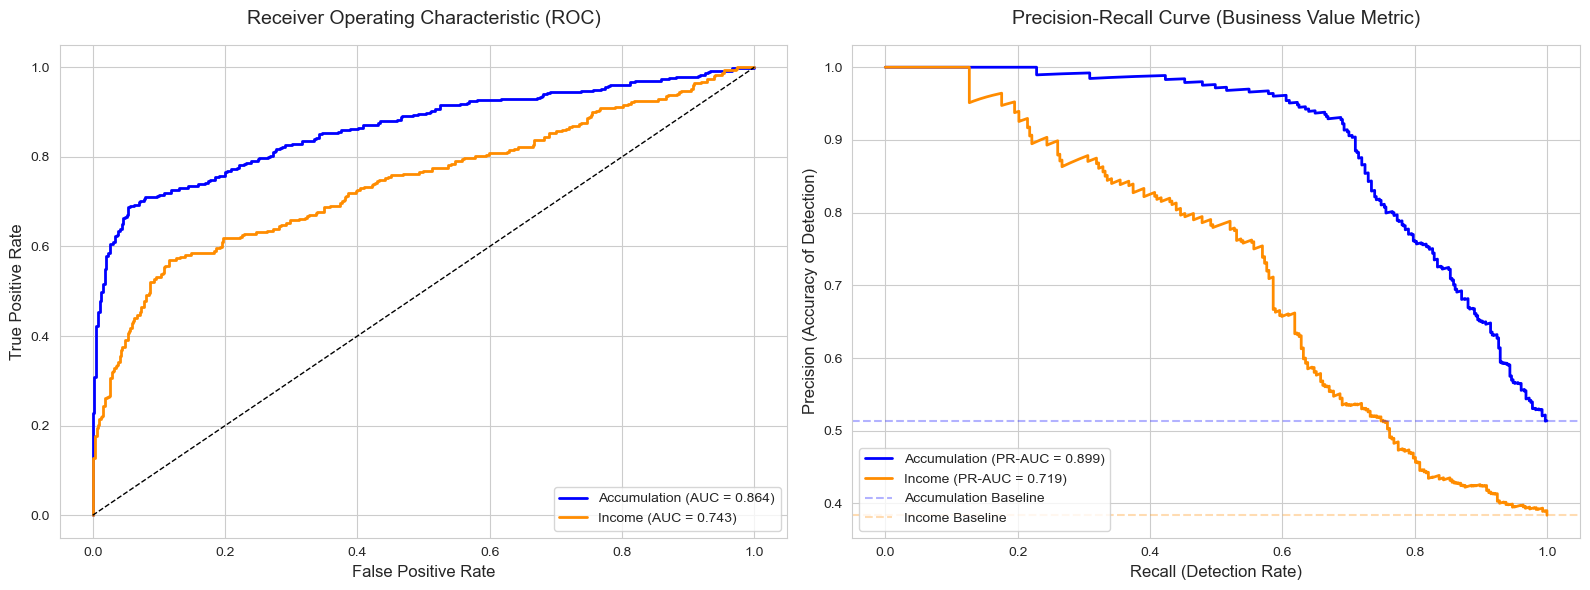

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc

print("--- VISUALIZING MULTI-TASK MODEL PERFORMANCE ---\n")

# Set aesthetic style
sns.set_style("whitegrid")

def plot_model_curves(y_true_acc, y_prob_acc, y_true_inc, y_prob_inc):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. ROC Curve ---
    fpr_acc, tpr_acc, _ = roc_curve(y_true_acc, y_prob_acc)
    fpr_inc, tpr_inc, _ = roc_curve(y_true_inc, y_prob_inc)
    
    axes[0].plot(fpr_acc, tpr_acc, label=f'Accumulation (AUC = {auc(fpr_acc, tpr_acc):.3f})', color='blue', lw=2)
    axes[0].plot(fpr_inc, tpr_inc, label=f'Income (AUC = {auc(fpr_inc, tpr_inc):.3f})', color='darkorange', lw=2)
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=15)
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].legend(loc='lower right', frameon=True)
    
    # --- 2. Precision-Recall Curve ---
    # PR Curves are much more important for imbalanced targets (like the Income class)
    prec_acc, rec_acc, _ = precision_recall_curve(y_true_acc, y_prob_acc)
    prec_inc, rec_inc, _ = precision_recall_curve(y_true_inc, y_prob_inc)
    
    # Calculate baseline (random guessing) for PR curves
    baseline_acc = sum(y_true_acc) / len(y_true_acc)
    baseline_inc = sum(y_true_inc) / len(y_true_inc)
    
    axes[1].plot(rec_acc, prec_acc, label=f'Accumulation (PR-AUC = {auc(rec_acc, prec_acc):.3f})', color='blue', lw=2)
    axes[1].plot(rec_inc, prec_inc, label=f'Income (PR-AUC = {auc(rec_inc, prec_inc):.3f})', color='darkorange', lw=2)
    axes[1].axhline(y=baseline_acc, color='blue', linestyle='--', alpha=0.3, label='Accumulation Baseline')
    axes[1].axhline(y=baseline_inc, color='darkorange', linestyle='--', alpha=0.3, label='Income Baseline')
    axes[1].set_title('Precision-Recall Curve (Business Value Metric)', fontsize=14, pad=15)
    axes[1].set_xlabel('Recall (Detection Rate)', fontsize=12)
    axes[1].set_ylabel('Precision (Accuracy of Detection)', fontsize=12)
    axes[1].legend(loc='lower left', frameon=True)
    
    plt.tight_layout()
    plt.show()

# Assuming val_targs_acc and val_preds_acc were saved from your validation loop in Cell 4
# We use the raw probabilities for the curves
plot_model_curves(val_targs_acc, val_preds_acc, val_targs_inc, val_preds_inc)

Running ablation (this takes ~2-3 minutes)...

Epoch 000 | Loss: 1.4559 | ROC-AUC (Acc/Inc): 0.706/0.699 | PR-AUC (Acc/Inc): 0.695/0.688
Epoch 010 | Loss: 1.1551 | ROC-AUC (Acc/Inc): 0.855/0.734 | PR-AUC (Acc/Inc): 0.892/0.713
Epoch 020 | Loss: 1.1389 | ROC-AUC (Acc/Inc): 0.858/0.732 | PR-AUC (Acc/Inc): 0.895/0.712
Epoch 030 | Loss: 1.1234 | ROC-AUC (Acc/Inc): 0.859/0.740 | PR-AUC (Acc/Inc): 0.895/0.718
Epoch 040 | Loss: 1.1114 | ROC-AUC (Acc/Inc): 0.863/0.745 | PR-AUC (Acc/Inc): 0.899/0.721
Epoch 050 | Loss: 1.0948 | ROC-AUC (Acc/Inc): 0.862/0.743 | PR-AUC (Acc/Inc): 0.897/0.721
Epoch 060 | Loss: 1.0944 | ROC-AUC (Acc/Inc): 0.865/0.748 | PR-AUC (Acc/Inc): 0.900/0.722
Epoch 070 | Loss: 1.0843 | ROC-AUC (Acc/Inc): 0.864/0.739 | PR-AUC (Acc/Inc): 0.900/0.721

Early stopping triggered at epoch 78. Restoring best weights.
Epoch 000 | Loss: 1.4578 | ROC-AUC (Acc/Inc): 0.706/0.699 | PR-AUC (Acc/Inc): 0.695/0.688
Epoch 010 | Loss: 1.1558 | ROC-AUC (Acc/Inc): 0.855/0.734 | PR-AUC (Acc/Inc): 0.

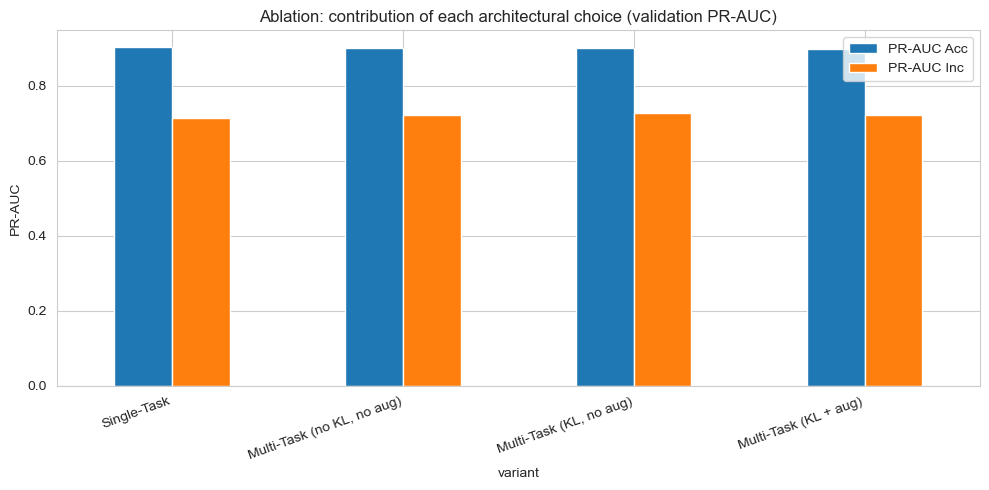

In [11]:
import copy
import torch.nn.functional as F
from dataclasses import dataclass
from sklearn.metrics import average_precision_score, roc_auc_score

@dataclass
class Variant:
    name: str
    multi_task: bool
    use_kl: bool
    use_augment: bool

variants = [
    Variant('Single-Task',                False, False, False),
    Variant('Multi-Task (no KL, no aug)',  True,  False, False),
    Variant('Multi-Task (KL, no aug)',     True,  True,  False),
    Variant('Multi-Task (KL + aug)',       True,  True,  True),
]

def train_single_head(in_dim, tr_ld, val_ld, pos_weight, target_idx, epochs=40,
                      seed=42):
    """
    target_idx: 0 -> Income, 1 -> Accumulation
    Returns validation probabilities (numpy).
    """
    torch.manual_seed(seed)
    m = SingleTaskMLP(in_dim=in_dim)
    opt = optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)

    for _ in range(epochs):
        m.train()
        for X_batch, y_inc_b, y_acc_b in tr_ld:
            targets = y_inc_b if target_idx == 0 else y_acc_b
            opt.zero_grad()
            logits = m(X_batch)
            loss = F.binary_cross_entropy_with_logits(logits, targets,
                                                      pos_weight=pos_weight)
            loss.backward()
            opt.step()

    m.eval()
    probs = []
    with torch.no_grad():
        for X_batch, _, _ in val_ld:
            probs.extend(torch.sigmoid(m(X_batch)).numpy())
    return np.array(probs)


def run_variant(v: Variant, seed: int = 42):
    torch.manual_seed(seed)
    tr_ds = FinancialNeedsDataset(X_train, y_train, augment=v.use_augment,
                                   noise_std=0.05, continuous_mask=continuous_mask)
    tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)

    ya = y_val['AccumulationInvestment'].values
    yi = y_val['IncomeInvestment'].values

    if v.multi_task:
        m = MultiTaskNeedsMLP(in_dim=len(feature_cols))
        opt = optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
        lam = 0.15 if v.use_kl else 0.0
        m, _ = train_multitask_model(m, tr_ld, val_loader, opt,
                                      w_a, w_i, joint_prior,
                                      epochs=100, patience=15, lam=lam)
        pa, pi, _, _ = get_raw_probs(m, val_loader)
    else:
        # Two separate single-task models, each with full capacity of one
        # multi-task branch (same SingleTaskMLP class from cell 3)
        pa = train_single_head(len(feature_cols), tr_ld, val_loader,
                               w_a, target_idx=1, seed=seed)
        pi = train_single_head(len(feature_cols), tr_ld, val_loader,
                               w_i, target_idx=0, seed=seed)

    return {
        'variant': v.name,
        'PR-AUC Acc':  average_precision_score(ya, pa),
        'PR-AUC Inc':  average_precision_score(yi, pi),
        'ROC-AUC Acc': roc_auc_score(ya, pa),
        'ROC-AUC Inc': roc_auc_score(yi, pi),
    }

print("Running ablation (this takes ~2-3 minutes)...\n")
results = [run_variant(v) for v in variants]
abl_df = pd.DataFrame(results).set_index('variant').round(4)
print(abl_df)

abl_df[['PR-AUC Acc', 'PR-AUC Inc']].plot(kind='bar', figsize=(10, 5))
plt.title('Ablation: contribution of each architectural choice (validation PR-AUC)')
plt.ylabel('PR-AUC')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


SHAP — Accumulation head: shap_values shape = (200, 20)


/var/folders/hs/9m7zchzx6gb534k85g2dfmnw0000gn/T/ipykernel_19508/2584907084.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


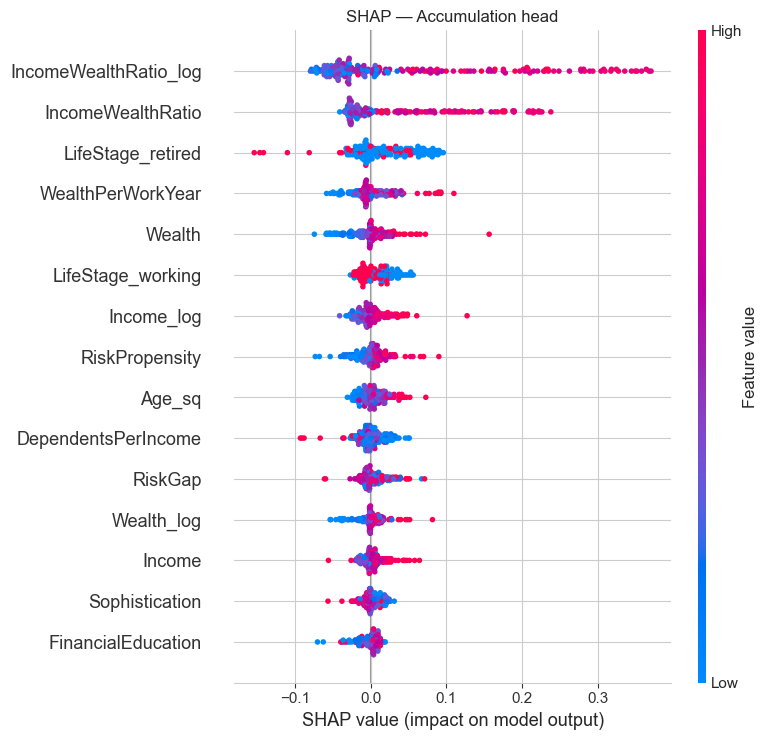

SHAP — Income head: shap_values shape = (200, 20)


/var/folders/hs/9m7zchzx6gb534k85g2dfmnw0000gn/T/ipykernel_19508/2584907084.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


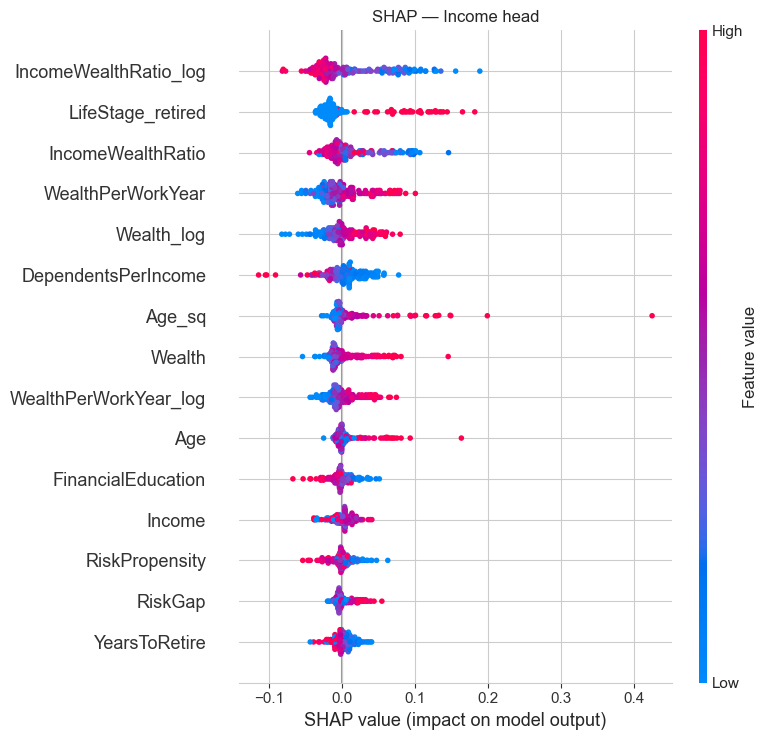

In [12]:
import shap
import numpy as np

# Wrap each head so DeepExplainer sees a single-output model
class HeadWrapper(torch.nn.Module):
    def __init__(self, base, head_name):
        super().__init__()
        self.base = base
        self.head_name = head_name  # 'accum' or 'income'
    def forward(self, x):
        la, li = self.base(x)
        out = la if self.head_name == 'accum' else li
        return torch.sigmoid(out).unsqueeze(-1)   # shape [batch, 1]

model.eval()

# Background sample (DeepExplainer baseline)
rng = np.random.RandomState(0)
bg_idx = rng.choice(len(X_train), size=100, replace=False)
bg_tensor = torch.tensor(X_train.values[bg_idx], dtype=torch.float32)

# Test subset to explain
n_explain = 200
test_sample = torch.tensor(X_test.values[:n_explain], dtype=torch.float32)
X_test_np = X_test.values[:n_explain]


def explain_head(head_name: str, title: str):
    wrapper = HeadWrapper(model, head_name)
    expl = shap.DeepExplainer(wrapper, bg_tensor)
    sv = expl.shap_values(test_sample, check_additivity=False)

    # Normalize SHAP output to 2D array [n_samples, n_features]
    # Different SHAP versions return list[ndarray] OR ndarray (2D or 3D)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[-1] == 1:
        sv = sv.squeeze(-1)              # drop trailing output dim
    assert sv.shape == (n_explain, len(feature_cols)), (
        f"Unexpected SHAP shape {sv.shape}, expected ({n_explain}, {len(feature_cols)})"
    )
    print(f"{title}: shap_values shape = {sv.shape}")

    shap.summary_plot(
        sv,
        X_test_np,
        feature_names=feature_cols,
        show=False,
        plot_type='dot',
        max_display=15,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


explain_head('accum',  'SHAP \u2014 Accumulation head')
explain_head('income', 'SHAP \u2014 Income head')


## Conceptual note on target labels

`IncomeInvestment` and `AccumulationInvestment` are **proxy labels derived from
observed holdings**, not direct measurements of client needs. They follow the
revealed-preference scheme described in the business case: a client is treated
as having a need if their (professionally vetted) advisor has matched them with
a product satisfying that need.

Two consequences of this we deliberately account for in the model:

1. **Label noise.** The model can only be as good as the advisor process it
   clones. Part of the motivation for the KL consistency term is to anchor the
   model on the *aggregate* behaviour of the advisor pool rather than
   overfitting individual calls.
2. **Selection bias.** Clients without a matching product have `y = 0`, but
   some of them may in fact have the need (it just wasn't acted on). This
   biases Recall downward and is a reason to take precision-oriented metrics
   with care. A production deployment should periodically re-label against
   post-recommendation acceptance data.